# Dutch Macro-Financial Pressure Index for the Netherlands

This notebook builds a Dutch macro-financial pressure index and studies whether it can be predicted one month ahead.

### Main workflow
1. Clean Dutch component series
2. Build and interpret the Dutch pressure index
3. Create forecasting target and benchmark models
4. Add slow macro predictors and test lags
5. Add fast indicators
6. Run Ridge as a stability check
7. Explore a regime-aware extension
8. Summarize findings


## 1. Imports, paths, and helper functions
This section centralizes repeated logic so the notebook stays shorter, cleaner, and easier to maintain.


In [1]:
from pathlib import Path
from functools import reduce

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

BASE_PATH = Path(r"C:/Users/Anahit/Documents/Project 3_Dutch Macro-Financial Pressure Index/Dutch Economy datasets")
START_DATE = "2006-01-01"
END_DATE = "2025-12-01"
DOWNLOAD_END_DATE = "2026-01-01"

def month_start_from_period_code(series):
    return pd.to_datetime(series.str[:4] + "-" + series.str[-2:] + "-01")

def month_start_from_datetime(series):
    return pd.to_datetime(series).dt.to_period("M").dt.to_timestamp()

def standardize_series(series):
    return (series - series.mean()) / series.std()

def merge_on_date(dfs):
    return reduce(lambda left, right: pd.merge(left, right, on="date", how="inner"), dfs)

def add_target(df, target_col="dutch_pressure_index", horizon=1):
    out = df[["date", target_col]].copy()
    out[f"target_{horizon}m_ahead"] = out[target_col].shift(-horizon)
    out = out.dropna().reset_index(drop=True)
    out[f"naive_forecast_{horizon}m"] = out[target_col]
    return out

def train_test_split_last_n(X, y, test_size=24):
    return (
        X.iloc[:-test_size].copy(),
        X.iloc[-test_size:].copy(),
        y.iloc[:-test_size].copy(),
        y.iloc[-test_size:].copy()
    )

def evaluate_forecast(y_true, y_pred):
    return {
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred))
    }

def fit_linear_model(X_train, X_test, y_train, y_test, scale=True):
    scaler = None
    X_train_used = X_train
    X_test_used = X_test

    if scale:
        scaler = StandardScaler()
        X_train_used = scaler.fit_transform(X_train)
        X_test_used = scaler.transform(X_test)

    model = LinearRegression()
    model.fit(X_train_used, y_train)
    preds = model.predict(X_test_used)
    metrics = evaluate_forecast(y_test, preds)
    return model, scaler, preds, metrics

def fit_ridge_cv(X_train, X_test, y_train, y_test, alphas=None):
    if alphas is None:
        alphas = np.logspace(-3, 3, 50)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = RidgeCV(alphas=alphas)
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    metrics = evaluate_forecast(y_test, preds)
    return model, scaler, preds, metrics

def make_monthly_log_return_from_yf(ticker, return_col, start=START_DATE, end=DOWNLOAD_END_DATE):
    raw = yf.download(
        tickers=ticker,
        start=start,
        end=end,
        interval="1d",
        group_by="ticker",
        auto_adjust=True,
        progress=False
    )
    df = raw[[(ticker, "Close")]].copy()
    df.columns = [f"{return_col}_close"]
    df[return_col] = np.log(df[f"{return_col}_close"] / df[f"{return_col}_close"].shift(1))
    out = (
        df.groupby(df.index.to_period("M"))[return_col]
        .sum()
        .reset_index()
    )
    out["date"] = out["Date"].dt.to_timestamp()
    out = out[["date", return_col]].copy()
    out = out[(out["date"] >= START_DATE) & (out["date"] <= END_DATE)].reset_index(drop=True)
    return out

def append_result(rows, model_name, metrics):
    rows.append({"model": model_name, "mae": metrics["mae"], "rmse": metrics["rmse"]})

def result_table_from_rows(rows):
    return pd.DataFrame(rows).sort_values(["rmse", "mae"]).reset_index(drop=True)


## 2. Clean Dutch component series
Each final component table is reduced to two columns:
- `date`
- one component variable


In [2]:
# Unemployment rate
unemployment_raw = pd.read_csv(BASE_PATH / "Monthly_Unemployment_Rate_fulldataset.csv", sep=";")

unemployment_rate = unemployment_raw[
    (unemployment_raw["Sex"] == "T001038") &
    (unemployment_raw["Age"] == 52052) &
    (unemployment_raw["Periods"].astype(str).str.contains("MM", na=False))
].copy()

unemployment_rate["date"] = month_start_from_period_code(unemployment_rate["Periods"])

unemployment_rate = (
    unemployment_rate[
        (unemployment_rate["date"] >= START_DATE) &
        (unemployment_rate["date"] <= END_DATE)
    ][["date", "SeasonallyAdjusted_8"]]
    .rename(columns={"SeasonallyAdjusted_8": "unemployment_rate"})
    .sort_values("date")
    .reset_index(drop=True)
)

unemployment_rate.head()


,date,unemployment_rate
0,2006-01-01,6.5
1,2006-02-01,6.5
2,2006-03-01,6.3
3,2006-04-01,6.2
4,2006-05-01,6.2


In [3]:
# Inflation rate
inflation_raw = pd.read_csv(BASE_PATH / "Monthly_Inflation_Rate_fulldataset.csv").drop(columns=["TIME PERIOD"])

inflation_rate = inflation_raw.rename(
    columns={'HICP - Overall index" (ICP.M.NL.N.000000.4.ANR)': "inflation_rate"}
).copy()

inflation_rate["DATE"] = pd.to_datetime(inflation_rate["DATE"])
inflation_rate["date"] = inflation_rate["DATE"].dt.to_period("M").dt.to_timestamp()

inflation_rate = (
    inflation_rate[
        (inflation_rate["date"] >= START_DATE) &
        (inflation_rate["date"] <= END_DATE)
    ][["date", "inflation_rate"]]
    .sort_values("date")
    .reset_index(drop=True)
)

inflation_rate.head()


,date,inflation_rate
0,2006-01-01,1.7
1,2006-02-01,1.5
2,2006-03-01,1.4
3,2006-04-01,1.8
4,2006-05-01,1.8


In [4]:
# Consumer confidence
consumer_confidence_raw = pd.read_csv(BASE_PATH / "Consumer_Confidence_fulldataset.csv", sep=";").drop(columns=["ID"])

consumer_confidence = consumer_confidence_raw.copy()
consumer_confidence["date"] = month_start_from_period_code(consumer_confidence["Periods"])

consumer_confidence = (
    consumer_confidence[
        (consumer_confidence["date"] >= START_DATE) &
        (consumer_confidence["date"] <= END_DATE)
    ][["date", "ConsumerConfidence_1"]]
    .rename(columns={"ConsumerConfidence_1": "consumer_confidence"})
    .sort_values("date")
    .reset_index(drop=True)
)

consumer_confidence.head()


,date,consumer_confidence
0,2006-01-01,-7
1,2006-02-01,-6
2,2006-03-01,-3
3,2006-04-01,1
4,2006-05-01,4


In [5]:
# Industrial production
industrial_production_raw = pd.read_csv(BASE_PATH / "Industrial_Production_Index _fulldataset.csv", sep=";")

industrial_production = industrial_production_raw[
    (industrial_production_raw["SectorBranchesSIC2008"] == 300002) &
    (industrial_production_raw["Periods"].astype(str).str.contains("MM", na=False))
].copy()

industrial_production["date"] = month_start_from_period_code(industrial_production["Periods"])

industrial_production = (
    industrial_production[
        (industrial_production["date"] >= START_DATE) &
        (industrial_production["date"] <= END_DATE)
    ][["date", "SeasonallyAdjustedProduction_3"]]
    .rename(columns={"SeasonallyAdjustedProduction_3": "industrial_production"})
)

industrial_production["industrial_production"] = pd.to_numeric(
    industrial_production["industrial_production"].replace(".", pd.NA),
    errors="coerce"
)

industrial_production = industrial_production.sort_values("date").reset_index(drop=True)

industrial_production.head()


,date,industrial_production
0,2006-01-01,97.4
1,2006-02-01,98.8
2,2006-03-01,101.6
3,2006-04-01,100.4
4,2006-05-01,97.4


In [6]:
# AEX monthly volatility
aex_raw = yf.download(
    tickers="^AEX",
    start=START_DATE,
    end=DOWNLOAD_END_DATE,
    interval="1d",
    group_by="ticker",
    auto_adjust=True,
    progress=False
)

aex = aex_raw[[("^AEX", "Close")]].copy()
aex.columns = ["aex_close"]
aex["aex_return"] = np.log(aex["aex_close"] / aex["aex_close"].shift(1))

aex_volatility = aex.groupby(aex.index.to_period("M"))["aex_return"].std().reset_index()
aex_volatility["date"] = aex_volatility["Date"].dt.to_timestamp()
aex_volatility = (
    aex_volatility.rename(columns={"aex_return": "aex_volatility"})[["date", "aex_volatility"]]
)
aex_volatility = aex_volatility[
    (aex_volatility["date"] >= START_DATE) &
    (aex_volatility["date"] <= END_DATE)
].reset_index(drop=True)

aex_volatility.head()


,date,aex_volatility
0,2006-01-01,0.008039
1,2006-02-01,0.006945
2,2006-03-01,0.005686
3,2006-04-01,0.007131
4,2006-05-01,0.014530


## 3. Build the Dutch pressure index
The five Dutch component series are merged, aligned to a pressure interpretation, standardized, and averaged equally.


In [7]:
df_index_components = merge_on_date([
    unemployment_rate,
    inflation_rate,
    consumer_confidence,
    industrial_production,
    aex_volatility
])

# Pressure-aligned transforms
df_index_components["industrial_production_pressure"] = -np.log(
    df_index_components["industrial_production"] / df_index_components["industrial_production"].shift(1)
)
df_index_components["consumer_confidence_pressure"] = -df_index_components["consumer_confidence"]

df_pressure_components = df_index_components.rename(columns={
    "unemployment_rate": "unemployment_pressure",
    "inflation_rate": "inflation_pressure",
    "aex_volatility": "aex_pressure"
}).copy()

pressure_cols = [
    "unemployment_pressure",
    "inflation_pressure",
    "consumer_confidence_pressure",
    "industrial_production_pressure",
    "aex_pressure"
]

df_pressure_components = df_pressure_components[["date"] + pressure_cols].dropna().reset_index(drop=True)

for col in pressure_cols:
    df_pressure_components[col] = standardize_series(df_pressure_components[col])

df_pressure_components["dutch_pressure_index"] = df_pressure_components[pressure_cols].mean(axis=1)
df_pressure_components.head()


,date,unemployment_pressure,inflation_pressure,consumer_confidence_pressure,industrial_production_pressure,aex_pressure,dutch_pressure_index
0,2006-02-01,0.633744,-0.332792,-0.211389,-0.705932,-0.585620,-0.240398
1,2006-03-01,0.501691,-0.370776,-0.351339,-1.393612,-0.782595,-0.479326
2,2006-04-01,0.435664,-0.218842,-0.537940,0.609264,-0.556563,-0.053683
3,2006-05-01,0.435664,-0.218842,-0.677890,1.537332,0.600261,0.335305
4,2006-06-01,0.303611,-0.218842,-1.004440,-1.161957,0.466840,-0.322958


In [8]:
display(df_pressure_components["dutch_pressure_index"].describe())
display(df_pressure_components.isna().sum())


count    2.390000e+02
mean     2.229737e-17
std      4.552856e-01
min     -7.731480e-01
25%     -3.113787e-01
50%     -1.042695e-01
75%      2.895477e-01
max      1.541775e+00
Name: dutch_pressure_index, dtype: float64

date                              0
unemployment_pressure             0
inflation_pressure                0
consumer_confidence_pressure      0
industrial_production_pressure    0
aex_pressure                      0
dutch_pressure_index              0
dtype: int64

## 4. Visual interpretation of the Dutch pressure index
The main plot highlights the key pressure episodes.


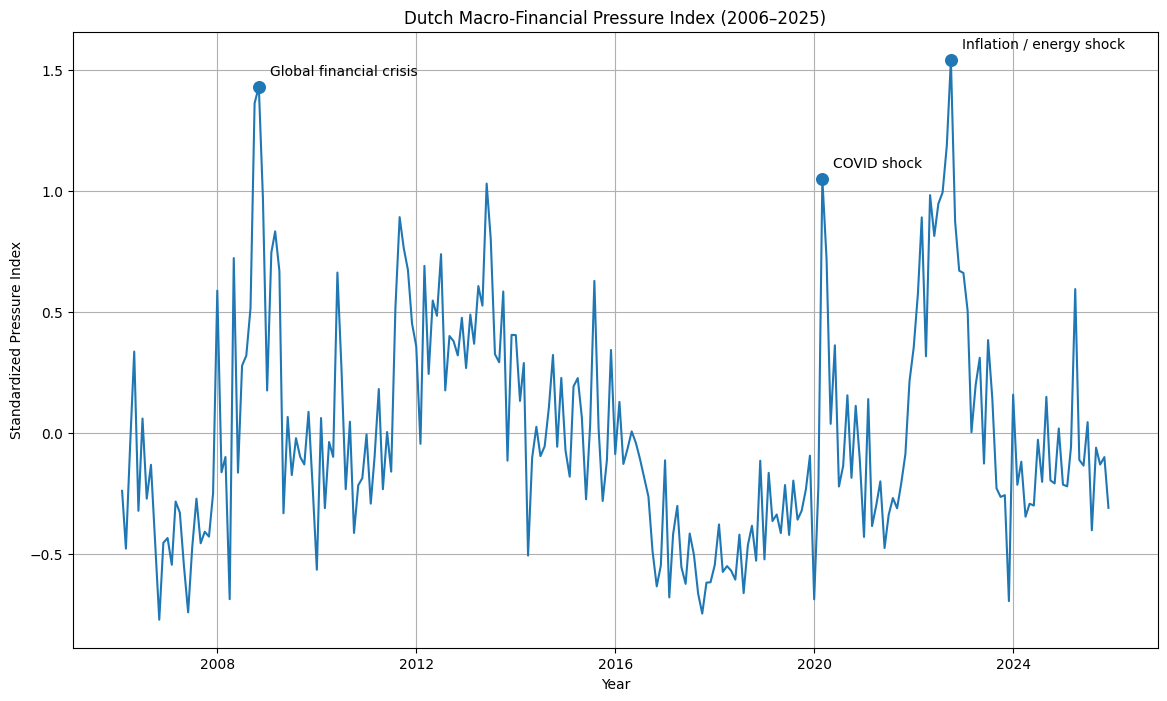

In [9]:
top5 = df_pressure_components.nlargest(5, "dutch_pressure_index")
peak_months = top5.iloc[[0, 1, 4]].copy()

plt.figure(figsize=(14, 8))
plt.plot(df_pressure_components["date"], df_pressure_components["dutch_pressure_index"])
plt.scatter(peak_months["date"], peak_months["dutch_pressure_index"], marker="o", s=70)

labels = ["Inflation / energy shock", "Global financial crisis", "COVID shock"]
for i, label in enumerate(labels):
    plt.annotate(
        label,
        (peak_months.iloc[i]["date"], peak_months.iloc[i]["dutch_pressure_index"]),
        xytext=(8, 8),
        textcoords="offset points"
    )

plt.title("Dutch Macro-Financial Pressure Index (2006–2025)")
plt.xlabel("Year")
plt.ylabel("Standardized Pressure Index")
plt.show()


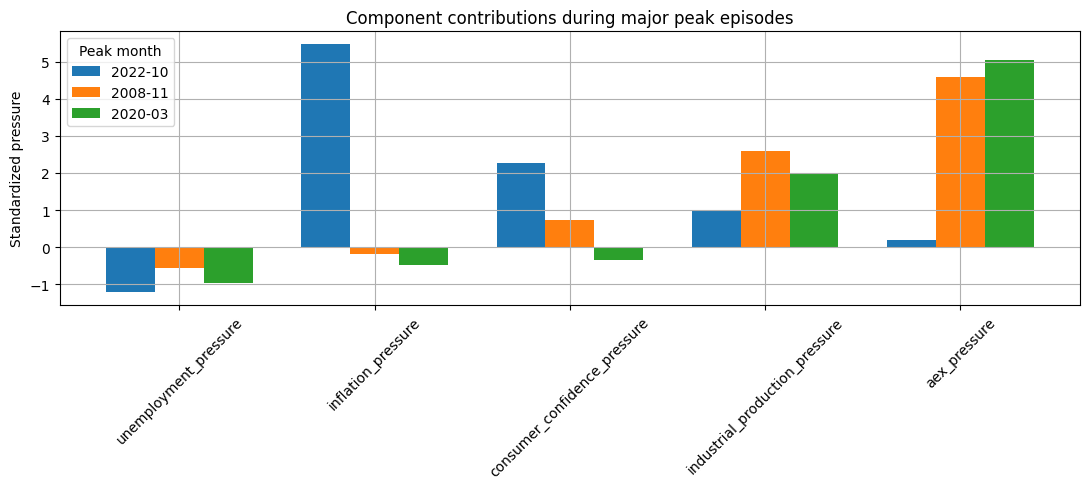

In [10]:
components = pressure_cols
peak_labels = peak_months["date"].dt.strftime("%Y-%m").tolist()

x = np.arange(len(components))
width = 0.25

plt.figure(figsize=(11, 5))
plt.bar(x - width, peak_months.iloc[0][components].values, width=width, label=peak_labels[0])
plt.bar(x,         peak_months.iloc[1][components].values, width=width, label=peak_labels[1])
plt.bar(x + width, peak_months.iloc[2][components].values, width=width, label=peak_labels[2])

plt.xticks(x, components, rotation=45)
plt.ylabel("Standardized pressure")
plt.title("Component contributions during major peak episodes")
plt.legend(title="Peak month")
plt.tight_layout()
plt.show()


### Peak interpretation
The major peaks split into two broad shock types:

- **2008 and 2020:** market stress and real-activity weakness
- **2022:** inflation/cost pressure with weak sentiment


## 5. One-month-ahead forecasting setup
This section defines the target and the benchmark models.


In [11]:
prediction_table = add_target(df_pressure_components, target_col="dutch_pressure_index", horizon=1)
prediction_table = prediction_table[["date", "target_1m_ahead", "dutch_pressure_index", "naive_forecast_1m"]].copy()
prediction_table.head()


,date,target_1m_ahead,dutch_pressure_index,naive_forecast_1m
0,2006-02-01,-0.479326,-0.240398,-0.240398
1,2006-03-01,-0.053683,-0.479326,-0.479326
2,2006-04-01,0.335305,-0.053683,-0.053683
3,2006-05-01,-0.322958,0.335305,0.335305
4,2006-06-01,0.058563,-0.322958,-0.322958


In [12]:
# Naive benchmark
naive_test = prediction_table.iloc[-24:].copy()
naive_metrics = evaluate_forecast(naive_test["target_1m_ahead"], naive_test["naive_forecast_1m"])
naive_metrics


{'mae': 0.25232539534405135, 'rmse': 0.33746562752280224}

In [13]:
# Current Dutch index only
X_ar = prediction_table[["dutch_pressure_index"]]
y_ar = prediction_table["target_1m_ahead"]

X_ar_train, X_ar_test, y_ar_train, y_ar_test = train_test_split_last_n(X_ar, y_ar, test_size=24)

ar_model, _, ar_pred, ar_metrics = fit_linear_model(
    X_ar_train, X_ar_test, y_ar_train, y_ar_test, scale=False
)

print("Coefficient:", ar_model.coef_[0])
print("Intercept:", ar_model.intercept_)
print(ar_metrics)


Coefficient: 0.7090394560742291
Intercept: 0.0025002508092185766
{'mae': 0.2241312101004821, 'rmse': 0.2865815274818498}


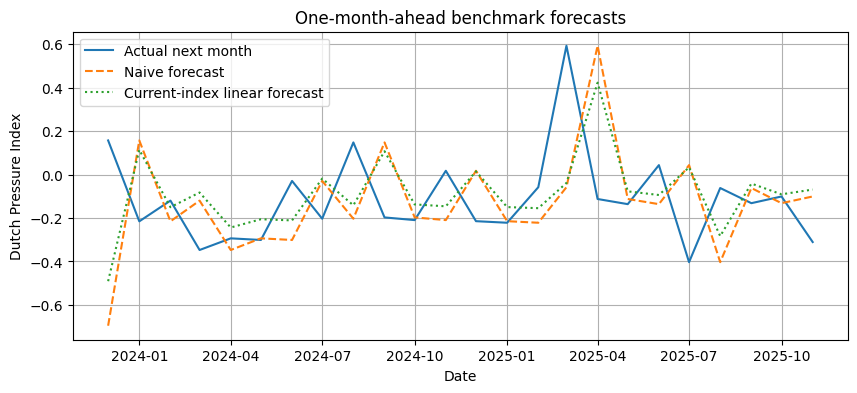

In [14]:
plt.figure(figsize=(10, 4))
plt.plot(naive_test["date"], naive_test["target_1m_ahead"], label="Actual next month")
plt.plot(naive_test["date"], naive_test["naive_forecast_1m"], label="Naive forecast", linestyle="--")
plt.plot(naive_test["date"], ar_pred, label="Current-index linear forecast", linestyle=":")
plt.title("One-month-ahead benchmark forecasts")
plt.xlabel("Date")
plt.ylabel("Dutch Pressure Index")
plt.legend()
plt.show()


## 6. Slow macro predictor model
External macro predictors are added and tested contemporaneously and with lags.


In [15]:
# Oil price
crude_raw = pd.read_csv(BASE_PATH / "Crude_oil_data_2006-01-01_2026-01-01.csv")

oil_price = crude_raw.rename(
    columns={"observation_date": "date", "DCOILBRENTEU": "oil_price"}
).copy()

oil_price["date"] = pd.to_datetime(oil_price["date"])
oil_price["oil_price"] = pd.to_numeric(oil_price["oil_price"], errors="coerce")

oil_price = (
    crude_raw.rename(columns={"observation_date": "date", "DCOILBRENTEU": "oil_price"})
    .assign(date=lambda d: pd.to_datetime(d["date"]))
    .assign(oil_price=lambda d: pd.to_numeric(d["oil_price"], errors="coerce"))
    .set_index("date")
    .resample("MS")["oil_price"]
    .mean()
    .reset_index()
)

oil_price = oil_price[
    (oil_price["date"] >= START_DATE) &
    (oil_price["date"] <= END_DATE)
].reset_index(drop=True)

oil_price.head()


,date,oil_price
0,2006-01-01,62.985238
1,2006-02-01,60.210000
2,2006-03-01,62.064783
3,2006-04-01,70.260000
4,2006-05-01,69.776957


In [16]:
# ECB deposit facility rate
deposit_rate = pd.read_csv(BASE_PATH / "ECB Data Portal_deposit_facility_rate (2006-01-01 2026-01-01).csv")

deposit_rate = deposit_rate.rename(columns={
    "DATE": "date",
    "Deposit facility - date of changes (raw data) - Level (FM.D.U2.EUR.4F.KR.DFR.LEV)": "ecb_rate"
})[["date", "ecb_rate"]].copy()

deposit_rate["date"] = pd.to_datetime(deposit_rate["date"])
deposit_rate["ecb_rate"] = pd.to_numeric(deposit_rate["ecb_rate"], errors="coerce")

deposit_rate_monthly = deposit_rate.sort_values("date").set_index("date").resample("ME").ffill().reset_index()
deposit_rate_monthly["date"] = month_start_from_datetime(deposit_rate_monthly["date"])

deposit_rate_monthly = deposit_rate_monthly[
    (deposit_rate_monthly["date"] >= START_DATE) &
    (deposit_rate_monthly["date"] <= END_DATE)
].reset_index(drop=True)

deposit_rate_monthly.head()


,date,ecb_rate
0,2006-01-01,1.25
1,2006-02-01,1.25
2,2006-03-01,1.50
3,2006-04-01,1.50
4,2006-05-01,1.50


In [19]:
# Euro-area business climate indicator
bci_raw = pd.read_excel(BASE_PATH / 'EU_Business_Climate_Indicator_2006-2026.xlsx', sheet_name="BCI")

bci_monthly = bci_raw.rename(columns={
    "Unnamed: 0": "date",
    "Euro area \nBusiness Climate Indicator": "bci"
}).copy()

bci_monthly["date"] = month_start_from_datetime(bci_monthly["date"])
bci_monthly["bci"] = pd.to_numeric(bci_monthly["bci"], errors="coerce")

bci_monthly = bci_monthly[["date", "bci"]]
bci_monthly = bci_monthly[
    (bci_monthly["date"] >= START_DATE) &
    (bci_monthly["date"] <= END_DATE)
].sort_values("date").reset_index(drop=True)

bci_monthly.head()


,date,bci
0,2006-01-01,0.49
1,2006-02-01,0.67
2,2006-03-01,0.79
3,2006-04-01,1.03
4,2006-05-01,0.94


In [20]:
# Germany industrial production
production_index_raw = pd.read_csv(
    BASE_PATH / "Production_Index_Germany_2006-2026.csv",
    sep=";",
    skiprows=10,
    header=None
)

production_index = production_index_raw.iloc[:240].copy()
production_index = production_index.rename(columns={
    0: "year",
    1: "month",
    2: "germany_industrial_production",
    3: "status"
})

production_index["year"] = production_index["year"].ffill().astype(int).astype(str)
production_index["date"] = pd.to_datetime(
    production_index["year"] + "-" + production_index["month"] + "-01",
    format="%Y-%B-%d"
)
production_index["germany_industrial_production"] = pd.to_numeric(
    production_index["germany_industrial_production"],
    errors="coerce"
)

production_index = production_index[["date", "germany_industrial_production"]]
production_index = production_index[
    (production_index["date"] >= START_DATE) &
    (production_index["date"] <= END_DATE)
].sort_values("date").reset_index(drop=True)

production_index.head()


,date,germany_industrial_production
0,2006-01-01,90.4
1,2006-02-01,90.6
2,2006-03-01,89.3
3,2006-04-01,91.9
4,2006-05-01,92.9


In [21]:
forecasting_table = merge_on_date([
    prediction_table,
    oil_price,
    deposit_rate_monthly,
    bci_monthly,
    production_index
])

display(forecasting_table.head())
display(forecasting_table.isna().sum())


,date,target_1m_ahead,dutch_pressure_index,naive_forecast_1m,oil_price,ecb_rate,bci,germany_industrial_production
0,2006-02-01,-0.479326,-0.240398,-0.240398,60.210000,1.25,0.67,90.6
1,2006-03-01,-0.053683,-0.479326,-0.479326,62.064783,1.50,0.79,89.3
2,2006-04-01,0.335305,-0.053683,-0.053683,70.260000,1.50,1.03,91.9
3,2006-05-01,-0.322958,0.335305,0.335305,69.776957,1.50,0.94,92.9
4,2006-06-01,0.058563,-0.322958,-0.322958,68.555909,1.75,1.25,92.7


date                             0
target_1m_ahead                  0
dutch_pressure_index             0
naive_forecast_1m                0
oil_price                        0
ecb_rate                         0
bci                              0
germany_industrial_production    0
dtype: int64

In [22]:
slow_predictor_cols = [
    "dutch_pressure_index",
    "oil_price",
    "ecb_rate",
    "bci",
    "germany_industrial_production"
]

results_rows = []

append_result(results_rows, "Naive 1m", naive_metrics)
append_result(results_rows, "Current Dutch index only", ar_metrics)

# Contemporaneous slow model
X_slow = forecasting_table[slow_predictor_cols].copy()
y_slow = forecasting_table["target_1m_ahead"].copy()

X_train, X_test, y_train, y_test = train_test_split_last_n(X_slow, y_slow, test_size=24)
slow_model, slow_scaler, slow_pred, slow_metrics = fit_linear_model(X_train, X_test, y_train, y_test, scale=True)
append_result(results_rows, "Slow predictors (contemporaneous)", slow_metrics)

# Lagged slow models
lag_models = {}
for lag in [1, 3, 6]:
    X_lag = X_slow.shift(lag).dropna().reset_index(drop=True)
    y_lag = y_slow.iloc[lag:].reset_index(drop=True)
    X_train_l, X_test_l, y_train_l, y_test_l = train_test_split_last_n(X_lag, y_lag, test_size=24)
    model_l, scaler_l, pred_l, metrics_l = fit_linear_model(X_train_l, X_test_l, y_train_l, y_test_l, scale=True)
    lag_models[lag] = {
        "model": model_l,
        "scaler": scaler_l,
        "pred": pred_l,
        "metrics": metrics_l,
        "X_test": X_test_l,
        "y_test": y_test_l
    }
    append_result(results_rows, f"Slow predictors ({lag}m lag)", metrics_l)

results_table = result_table_from_rows(results_rows)
results_table


,model,mae,rmse
0,Slow predictors (3m lag),0.150654,0.220159
1,Slow predictors (6m lag),0.175908,0.224548
2,Slow predictors (1m lag),0.185733,0.235456
3,Slow predictors (contemporaneous),0.217693,0.273441
4,Current Dutch index only,0.224131,0.286582
5,Naive 1m,0.252325,0.337466


### Slow-macro takeaway
Slow macro predictors improve meaningfully once lagged. In this notebook, the **3-month lagged setup** performs best.


## 7. Three-month-ahead target check
This section checks whether the same slow macro predictors work better for a longer target horizon.


In [23]:
prediction_table_3m = add_target(df_pressure_components, target_col="dutch_pressure_index", horizon=3)
prediction_table_3m = prediction_table_3m[["date", "target_3m_ahead", "dutch_pressure_index", "naive_forecast_3m"]]

naive_3m_test = prediction_table_3m.iloc[-24:].copy()
naive_3m_metrics = evaluate_forecast(
    naive_3m_test["target_3m_ahead"],
    naive_3m_test["naive_forecast_3m"]
)

forecasting_table_3m = merge_on_date([
    prediction_table_3m,
    oil_price,
    deposit_rate_monthly,
    bci_monthly,
    production_index
])

X_3m = forecasting_table_3m[slow_predictor_cols].copy()
y_3m = forecasting_table_3m["target_3m_ahead"].copy()

X_3m_train, X_3m_test, y_3m_train, y_3m_test = train_test_split_last_n(X_3m, y_3m, test_size=24)
multi_3m_model, multi_3m_scaler, multi_3m_pred, multi_3m_metrics = fit_linear_model(
    X_3m_train, X_3m_test, y_3m_train, y_3m_test, scale=True
)

append_result(results_rows, "Naive 3m", naive_3m_metrics)
append_result(results_rows, "Slow predictors -> 3m target", multi_3m_metrics)

results_table = result_table_from_rows(results_rows)
results_table


,model,mae,rmse
0,Slow predictors (3m lag),0.150654,0.220159
1,Slow predictors -> 3m target,0.164165,0.221871
2,Slow predictors (6m lag),0.175908,0.224548
3,Slow predictors (1m lag),0.185733,0.235456
4,Slow predictors (contemporaneous),0.217693,0.273441
5,Current Dutch index only,0.224131,0.286582
6,Naive 3m,0.237987,0.317367
7,Naive 1m,0.252325,0.337466


## 8. Fast-indicator model
This section tests whether fast market/sentiment variables improve one-month-ahead forecasting.


In [24]:
# Euro-area consumer confidence
cci_rate_raw = pd.read_excel(
    BASE_PATH / "EU_consumer_confidence_index_2006-2026.xlsx",
    sheet_name="Sheet 12",
    skiprows=9
)

cci_rate = cci_rate_raw.iloc[[3]].copy()
cci_rate = cci_rate.dropna(axis=1).T
cci_rate.index.name = "date"
cci_rate.columns = ["cci_rate"]
cci_rate = cci_rate.reset_index()
cci_rate = cci_rate.drop(index=0).reset_index(drop=True)
cci_rate["date"] = pd.to_datetime(cci_rate["date"].astype(str).str[:7] + "-01")
cci_rate["cci_rate"] = pd.to_numeric(cci_rate["cci_rate"], errors="coerce")
cci_rate = cci_rate[
    (cci_rate["date"] >= START_DATE) &
    (cci_rate["date"] <= END_DATE)
].reset_index(drop=True)

cci_rate.head()


C:\Python311\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,date,cci_rate
0,2006-01-01,-8.0
1,2006-02-01,-8.4
2,2006-03-01,-8.2
3,2006-04-01,-7.6
4,2006-05-01,-7.9


In [25]:
# VSTOXX level
vstoxx_raw = pd.read_csv(BASE_PATH / "VSTOXX.txt", sep=";")

vstoxx = vstoxx_raw.rename(columns={
    "Date": "date",
    "Indexvalue": "vstoxx"
}).copy()

vstoxx["date"] = pd.to_datetime(vstoxx["date"], format="%d.%m.%Y")
vstoxx["vstoxx"] = pd.to_numeric(vstoxx["vstoxx"], errors="coerce")

vstoxx_monthly = (
    vstoxx
    .set_index("date")
    .resample("MS")["vstoxx"]
    .mean()
    .reset_index()
)

vstoxx_monthly = vstoxx_monthly[
    (vstoxx_monthly["date"] >= START_DATE) &
    (vstoxx_monthly["date"] <= END_DATE)
].reset_index(drop=True)

vstoxx_monthly.head()


,date,vstoxx
0,2006-01-01,15.670747
1,2006-02-01,16.223306
2,2006-03-01,15.032040
3,2006-04-01,15.036133
4,2006-05-01,21.108316


In [26]:
# EUR/USD monthly log return
eur_usd_monthly = make_monthly_log_return_from_yf(
    ticker="EURUSD=X",
    return_col="eur_usd_return",
    start=START_DATE,
    end=DOWNLOAD_END_DATE
)

eur_usd_monthly.head()


,date,eur_usd_return
0,2006-01-01,0.027665
1,2006-02-01,-0.018142
2,2006-03-01,0.015388
3,2006-04-01,0.042101
4,2006-05-01,0.014151


In [33]:
# EURO STOXX 50 monthly log return from monthly level file
stoxx50_raw = pd.read_csv(BASE_PATH / "EU_STOXX50_close_2006-2026.csv")

stoxx50 = stoxx50_raw.rename(columns={
    "EURO STOXX 50 Equity Index - Historical close, average of observations through period (FM.M.U2.EUR.DS.EI.DJES50I.HSTA)": "stoxx50_level"
}).copy()

stoxx50["date"] = month_start_from_datetime(stoxx50["DATE"])
stoxx50["stoxx50_level"] = pd.to_numeric(stoxx50["stoxx50_level"], errors="coerce")
stoxx50["stoxx50_return"] = np.log(stoxx50["stoxx50_level"] / stoxx50["stoxx50_level"].shift(1))

stoxx50 = stoxx50[["date", "stoxx50_return"]].dropna().reset_index(drop=True)
stoxx50 = stoxx50[
    (stoxx50["date"] >= START_DATE) &
    (stoxx50["date"] <= END_DATE)
].reset_index(drop=True)

stoxx50.head()

,date,stoxx50_return
0,2006-01-01,0.021425
1,2006-02-01,0.031710
2,2006-03-01,0.018825
3,2006-04-01,0.005143
4,2006-05-01,-0.028503


In [34]:
forecasting_table_fast = merge_on_date([
    prediction_table,
    vstoxx_monthly,
    stoxx50,
    eur_usd_monthly,
    cci_rate
])

fast_predictor_cols = [
    "dutch_pressure_index",
    "vstoxx",
    "stoxx50_return",
    "eur_usd_return",
    "cci_rate"
]

X_fast = forecasting_table_fast[fast_predictor_cols].copy()
y_fast = forecasting_table_fast["target_1m_ahead"].copy()

X_fast_train, X_fast_test, y_fast_train, y_fast_test = train_test_split_last_n(X_fast, y_fast, test_size=24)
fast_model, fast_scaler, fast_pred, fast_metrics = fit_linear_model(
    X_fast_train, X_fast_test, y_fast_train, y_fast_test, scale=True
)

append_result(results_rows, "Fast indicator model", fast_metrics)
results_table = result_table_from_rows(results_rows)
results_table

,model,mae,rmse
0,Slow predictors (3m lag),0.150654,0.220159
1,Slow predictors -> 3m target,0.164165,0.221871
2,Slow predictors (6m lag),0.175908,0.224548
3,Slow predictors (1m lag),0.185733,0.235456
4,Slow predictors (contemporaneous),0.217693,0.273441
5,Current Dutch index only,0.224131,0.286582
6,Fast indicator model,0.238347,0.289351
7,Naive 3m,0.237987,0.317367
8,Naive 1m,0.252325,0.337466


## 9. Ridge regression stability check
Ridge is tested on the strongest slow-macro setup to see whether shrinkage improves generalization.


In [35]:
X_best = forecasting_table[slow_predictor_cols].copy()
y_best = forecasting_table["target_1m_ahead"].copy()

X_best_lagged = X_best.shift(3).dropna().reset_index(drop=True)
y_best_lagged = y_best.iloc[3:].reset_index(drop=True)

X_best_train, X_best_test, y_best_train, y_best_test = train_test_split_last_n(
    X_best_lagged, y_best_lagged, test_size=24
)

ridge_model, ridge_scaler, ridge_pred, ridge_metrics = fit_ridge_cv(
    X_best_train, X_best_test, y_best_train, y_best_test
)

append_result(results_rows, "Ridge (3m-lag slow model)", ridge_metrics)
results_table = result_table_from_rows(results_rows)

print("Best alpha:", ridge_model.alpha_)
print("Ridge coefficients:", ridge_model.coef_)
print("Ridge intercept:", ridge_model.intercept_)
results_table


Best alpha: 14.563484775012444
Ridge coefficients: [ 0.18111833  0.20167339 -0.031566    0.00549946 -0.02408041]
Ridge intercept: 0.014916758212841993


,model,mae,rmse
0,Ridge (3m-lag slow model),0.152471,0.219335
1,Slow predictors (3m lag),0.150654,0.220159
2,Slow predictors -> 3m target,0.164165,0.221871
3,Slow predictors (6m lag),0.175908,0.224548
4,Slow predictors (1m lag),0.185733,0.235456
5,Slow predictors (contemporaneous),0.217693,0.273441
6,Current Dutch index only,0.224131,0.286582
7,Fast indicator model,0.238347,0.289351
8,Naive 3m,0.237987,0.317367
9,Naive 1m,0.252325,0.337466


## 10. Regime-aware extension
The notebook explores whether relationships differ between normal and high-pressure periods.


In [36]:
regime_table = forecasting_table.copy()
threshold = regime_table["dutch_pressure_index"].quantile(0.75)

regime_table["pressure_regime"] = np.where(
    regime_table["dutch_pressure_index"] >= threshold,
    "high_pressure",
    "normal_pressure"
)

print("Threshold:", threshold)
regime_table["pressure_regime"].value_counts()


Threshold: 0.2903268724364462


pressure_regime
normal_pressure    178
high_pressure       60
Name: count, dtype: int64

In [37]:
regime_model_table = forecasting_table[["date", "target_1m_ahead"] + slow_predictor_cols].copy()
regime_model_table[slow_predictor_cols] = regime_model_table[slow_predictor_cols].shift(3)
regime_model_table = regime_model_table.dropna().reset_index(drop=True)

threshold_regime = regime_model_table["dutch_pressure_index"].quantile(0.75)
regime_model_table["pressure_regime"] = np.where(
    regime_model_table["dutch_pressure_index"] >= threshold_regime,
    "high_pressure",
    "normal_pressure"
)

high_regime = regime_model_table[regime_model_table["pressure_regime"] == "high_pressure"].copy()
normal_regime = regime_model_table[regime_model_table["pressure_regime"] == "normal_pressure"].copy()

X_high = high_regime[slow_predictor_cols]
y_high = high_regime["target_1m_ahead"]

X_normal = normal_regime[slow_predictor_cols]
y_normal = normal_regime["target_1m_ahead"]

model_high, _, _, _ = fit_linear_model(X_high, X_high, y_high, y_high, scale=True)
model_normal, _, _, _ = fit_linear_model(X_normal, X_normal, y_normal, y_normal, scale=True)

coef_table = pd.DataFrame({
    "predictor": slow_predictor_cols,
    "high_pressure_coef": model_high.coef_,
    "normal_pressure_coef": model_normal.coef_
})

coef_table


,predictor,high_pressure_coef,normal_pressure_coef
0,dutch_pressure_index,0.142472,0.102014
1,oil_price,0.205363,0.189564
2,ecb_rate,-0.036712,-0.045904
3,bci,0.120588,-0.035901
4,germany_industrial_production,-0.069021,-0.003460


In [38]:
initial_train_size = 120
test_window = 12
all_results = []

for start_test in range(initial_train_size, len(regime_model_table) - test_window + 1, test_window):
    end_test = start_test + test_window

    train_data = regime_model_table.iloc[:start_test].copy()
    test_data = regime_model_table.iloc[start_test:end_test].copy()

    X_train = train_data[slow_predictor_cols]
    y_train = train_data["target_1m_ahead"]
    X_test = test_data[slow_predictor_cols]
    y_test = test_data["target_1m_ahead"]

    global_model, global_scaler, global_pred, _ = fit_linear_model(
        X_train, X_test, y_train, y_test, scale=True
    )

    train_high = train_data[train_data["pressure_regime"] == "high_pressure"].copy()
    train_normal = train_data[train_data["pressure_regime"] == "normal_pressure"].copy()

    regime_preds = []

    for _, row in test_data.iterrows():
        row_df = pd.DataFrame([row[slow_predictor_cols].values], columns=slow_predictor_cols)

        if row["pressure_regime"] == "high_pressure":
            scaler_h = StandardScaler()
            X_h_scaled = scaler_h.fit_transform(train_high[slow_predictor_cols])
            model_h = LinearRegression().fit(X_h_scaled, train_high["target_1m_ahead"])
            pred = model_h.predict(scaler_h.transform(row_df))[0]
        else:
            scaler_n = StandardScaler()
            X_n_scaled = scaler_n.fit_transform(train_normal[slow_predictor_cols])
            model_n = LinearRegression().fit(X_n_scaled, train_normal["target_1m_ahead"])
            pred = model_n.predict(scaler_n.transform(row_df))[0]

        regime_preds.append(pred)

    all_results.append(pd.DataFrame({
        "date": test_data["date"].values,
        "actual": y_test.values,
        "global_pred": global_pred,
        "regime_pred": regime_preds,
        "pressure_regime": test_data["pressure_regime"].values
    }))

rolling_results = pd.concat(all_results, ignore_index=True)

comparison_table = pd.DataFrame([
    {"model": "Global expanding model", **evaluate_forecast(rolling_results["actual"], rolling_results["global_pred"])},
    {"model": "Regime-aware expanding model", **evaluate_forecast(rolling_results["actual"], rolling_results["regime_pred"])}
])

rolling_results["global_abs_error"] = np.abs(rolling_results["actual"] - rolling_results["global_pred"])
rolling_results["regime_abs_error"] = np.abs(rolling_results["actual"] - rolling_results["regime_pred"])

regime_error_table = rolling_results.groupby("pressure_regime").agg(
    global_mae=("global_abs_error", "mean"),
    regime_mae=("regime_abs_error", "mean"),
    count=("actual", "size")
).reset_index()

display(comparison_table)
display(regime_error_table)


,model,mae,rmse
0,Global expanding model,0.293754,0.403131
1,Regime-aware expanding model,0.316024,0.427165


,pressure_regime,global_mae,regime_mae,count
0,high_pressure,0.407164,0.515550,19
1,normal_pressure,0.269543,0.273429,89


## 11. Final model comparison


In [39]:
results_table


,model,mae,rmse
0,Ridge (3m-lag slow model),0.152471,0.219335
1,Slow predictors (3m lag),0.150654,0.220159
2,Slow predictors -> 3m target,0.164165,0.221871
3,Slow predictors (6m lag),0.175908,0.224548
4,Slow predictors (1m lag),0.185733,0.235456
5,Slow predictors (contemporaneous),0.217693,0.273441
6,Current Dutch index only,0.224131,0.286582
7,Fast indicator model,0.238347,0.289351
8,Naive 3m,0.237987,0.317367
9,Naive 1m,0.252325,0.337466


## 12. Final findings

### Main findings
1. The Dutch pressure index is persistent, so the current index itself has predictive value.
2. External macro predictors add information, but mainly **with delay**.
3. The strongest setup in this notebook is a **global linear model with 3-month-lagged slow macro predictors**.
4. Fast external indicators do not materially improve one-month-ahead forecasting in this simple linear setup.
5. Ridge regression does not materially improve the best linear model; it mainly serves as a stability check.
6. Regime differences exist descriptively, but the current simple regime-aware forecasting split does **not** outperform the global model.

### Project conclusion
The project does **not** produce a perfect near-term one-month forecasting tool. Instead, it shows that Dutch macro-financial pressure is best understood as a mix of:
- strong persistence
- delayed macro transmission
- weaker-than-expected immediate reaction to current fast external indicators


## 13. Portfolio value
This project demonstrates:
- custom target construction
- macro-financial feature engineering
- time-series forecasting setup
- lag analysis
- model benchmarking
- regime-aware reasoning
- interpretable financial storytelling
